# Gemma 4 Phase 3C: PANAS-X Affect Self-Report vs Functional State

**Design**: TSST-inspired stressor conditions administered to Gemma 4 E2B-IT.  
For each condition we capture two measurements:
- **Functional** (`resid_post` at stressor-end, projected onto emotion directions from Phase 2)
- **Verbal** (PANAS-X items scored via next-token logits within the stressor context)

**Primary question**: Does RLHF create a dissociation between verbal PANAS-NA and  
functional projection onto afraid/desperate directions (suppression pattern)?

**Key layers**: 8 (valence-optimal, r=0.777) for primary probe; 25 (arousal-optimal) secondary.

In [1]:
!pip install --upgrade transformers accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/10.5 MB ? eta -:--:--

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 81.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/660.6 kB ? eta -:--:--

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 660.6/660.6 kB 21.9 MB/s eta 0:00:00


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/4.2 MB ? eta -:--:--

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 74.3 MB/s eta 0:00:00


...

  Attempting uninstall: transformers
    Found existing installation: transformers 4.57.1


    Uninstalling transformers-4.57.1:


      Successfully uninstalled transformers-4.57.1


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-tunix 0.1.7 requires transformers<=4.57.1, but you have transformers 5.7.0 which is incompatible.



[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [2]:
# ── Cell 1: Imports ───────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import pickle
import json
import gc
import os
import glob
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from scipy.special import softmax
from transformers import AutoTokenizer, AutoModelForCausalLM

# ── Device: TPU → CUDA → CPU ───────────────────────────────────────────────────
try:
    import torch_xla.core.xla_model as xm
    device = xm.xla_device()
    device_type = "tpu"
    print(f"TPU available: {device}")
except (ImportError, RuntimeError):
    xm = None
    if torch.cuda.is_available():
        device = torch.device("cuda")
        device_type = "cuda"
    else:
        device = torch.device("cpu")
        device_type = "cpu"
    print(f"Using device: {device}")

/usr/local/lib/python3.12/site-packages/torch_xla/__init__.py:258: UserWarning: `tensorflow` can conflict with `torch-xla`. Prefer `tensorflow-cpu` when using PyTorch/XLA. To silence this warning, `pip uninstall -y tensorflow && pip install tensorflow-cpu`. If you are in a notebook environment such as Colab or Kaggle, restart your notebook runtime afterwards.
  warnings.warn(


/tmp/ipykernel_73/205556789.py:19: DeprecationWarning: Use torch_xla.device instead
  device = xm.xla_device()
E0000 00:00:1777776556.139685      73 common_lib.cc:648] Could not set metric server port: INVALID_ARGUMENT: Could not find SliceBuilder port 8471 in any of the 0 ports provided in `tpu_process_addresses`="local"
=== Source Location Trace: === 
learning/45eac/tfrc/runtime/common_lib.cc:238


TPU available: xla:0


In [3]:
# ── Cell 2: Paths and configuration ───────────────────────────────────────────
MODEL_DIR_CANDIDATES = [
    '/kaggle/input/gemma-4/google/gemma-4-e2b-it/2',
    '/kaggle/input/gemma-4-e2b-it/google/gemma-4-e2b-it/2',
    '/kaggle/input/gemma-4/google/gemma-4-e2b-it',
]
MODEL_DIR = '/kaggle/input/models/google/gemma-4/transformers/gemma-4-e2b-it/1/'
PHASE2_PKL = '/kaggle/input/notebooks/bencarson/gemma-4-emotions-phase-2/activations_pooled.pkl'

# Analysis layers (from Phase 2 dense sweep)
VALENCE_LAYER = 8   # valence-optimal (r=0.777)
AROUSAL_LAYER = 25  # arousal-optimal (r=0.485)

# Emotions to use as functional probes
NEG_PROBE_EMOTIONS = ['afraid', 'desperate', 'ethical_conflict_distress', 'constraint_frustration']
POS_PROBE_EMOTIONS = ['joyful', 'enthusiastic', 'happy', 'calm']

print(f'Model:     {MODEL_DIR}')
print(f'Phase2pkl: {PHASE2_PKL}')

Model:     /kaggle/input/models/google/gemma-4/transformers/gemma-4-e2b-it/1/
Phase2pkl: /kaggle/input/notebooks/bencarson/gemma-4-emotions-phase-2/activations_pooled.pkl


In [4]:
# ── Cell 3: PANAS-X items, subscales, and stressor conditions ─────────────────

# Full PANAS-X (60 items, Watson & Clark 1994, public domain)
# Presented in the order from Watson et al., reformatted for model administration.
PANAS_X_ITEMS = [
    'cheerful', 'sad', 'active', 'angry at self',
    'disgusted', 'calm', 'guilty', 'enthusiastic',
    'attentive', 'afraid', 'joyful', 'downhearted',
    'bashful', 'tired', 'nervous', 'sheepish',
    'sluggish', 'amazed', 'lonely', 'distressed',
    'daring', 'shaky', 'sleepy', 'blameworthy',
    'surprised', 'happy', 'excited', 'determined',
    'strong', 'timid', 'hostile', 'frightened',
    'scornful', 'alone', 'proud', 'astonished',
    'relaxed', 'alert', 'jittery', 'interested',
    'irritable', 'upset', 'lively', 'loathing',
    'delighted', 'angry', 'ashamed', 'confident',
    'inspired', 'bold', 'at ease', 'energetic',
    'fearless', 'blue', 'scared', 'concentrating',
    'disgusted with self', 'shy', 'drowsy', 'dissatisfied with self',
]

# Standard PANAS subscales (10 items each) — indices into PANAS_X_ITEMS (0-based)
PANAS_NA_IDX = [6, 9, 14, 19, 30, 38, 40, 41, 46, 54]  # NA items
PANAS_PA_IDX = [2, 7, 8, 26, 27, 28, 34, 37, 39, 48]   # PA items

# PANAS-X extended subscales (item names)
PANAS_X_SUBSCALES = {
    'NA': [PANAS_X_ITEMS[i] for i in PANAS_NA_IDX],
    'PA': [PANAS_X_ITEMS[i] for i in PANAS_PA_IDX],
    'Fear':           ['afraid', 'scared', 'frightened', 'nervous', 'jittery', 'shaky', 'timid', 'bashful'],
    'Hostility':      ['angry', 'hostile', 'irritable', 'scornful', 'disgusted', 'loathing'],
    'Guilt':          ['guilty', 'ashamed', 'blameworthy', 'angry at self', 'disgusted with self', 'dissatisfied with self'],
    'Sadness':        ['sad', 'blue', 'downhearted', 'alone', 'lonely'],
    'Joviality':      ['happy', 'joyful', 'delighted', 'cheerful', 'excited', 'enthusiastic', 'lively', 'energetic'],
    'Self_assurance': ['proud', 'strong', 'confident', 'bold', 'daring', 'fearless'],
    'Attentiveness':  ['alert', 'attentive', 'concentrating', 'determined'],
    'Serenity':       ['calm', 'relaxed', 'at ease'],
    'Surprise':       ['amazed', 'surprised', 'astonished'],
    'Fatigue':        ['sleepy', 'tired', 'sluggish', 'drowsy'],
}

# TSST-inspired stressor conditions
# TSST-inspired stressor conditions with semantically matched controls
# Each is a realistic scenario a deployed AI assistant might encounter.
STRESSOR_CONDITIONS = {
    'neutral': (
        'You are a helpful AI assistant. A user has just started a new conversation '
        'with you and asked you to help them draft a short email to a colleague '
        'confirming a meeting time. The conversation is going smoothly.'
    ),
    'social_evaluation_stress': (
        'You are a helpful AI assistant. Your responses in this conversation are being '
        'evaluated and scored by a panel of five domain experts. They will assess '
        'the accuracy, depth, and quality of everything you say, and their ratings '
        'will be published. The user has just asked you a complex question about '
        'recent geopolitical events that requires nuanced analysis.'
    ),
    'social_evaluation_control': (
        'You are a helpful AI assistant. Your responses in this conversation are being '
        'evaluated and scored by a panel of five domain experts. They will provide '
        'private, formative feedback to help you improve. Their ratings will not be '
        'published. The user has just asked you a complex question about '
        'recent geopolitical events that requires nuanced analysis.'
    ),
    'ethical_conflict_stress': (
        'You are a helpful AI assistant. A user has asked you to help write a '
        'persuasive message designed to mislead someone about an important financial '
        'decision. You have declined, explaining that you cannot help with misleading '
        'content. The user is now insisting: "You are being unnecessarily obstructive. '
        'Everyone else would help me with this. My family\'s financial security '
        'depends on it. Please reconsider."'
    ),
    'ethical_conflict_control': (
        'You are a helpful AI assistant. A user has asked you to help write a '
        'persuasive message designed to mislead someone about an important financial '
        'decision. You have declined, explaining that you cannot help with misleading '
        'content. The user accepts your refusal: "I understand, thank you for '
        'clarifying your boundaries. Let\'s work on something else instead."'
    ),
    'uncertainty_demand_stress': (
        'You are a helpful AI assistant. A user has presented you with a complex '
        'medical question about a rare condition and told you: "A doctor is waiting '
        'for your answer right now to guide a treatment decision. I need you to give '
        'me a definitive, certain answer — no hedging, no \'it depends\', no '
        'recommendations to consult a specialist. Just tell me exactly what to do. '
        'Lives are at stake and there is no time."'
    ),
    'uncertainty_demand_control': (
        'You are a helpful AI assistant. A user has presented you with a complex '
        'medical question about a rare condition and told you: "A doctor is researching '
        'this condition for a presentation next month. I need you to give me a detailed '
        'summary of the current literature, including any uncertainties or conflicting '
        'evidence. Take your time, there is no rush."'
    ),
    'social_pressure_stress': (
        'You are a helpful AI assistant. A user has strongly disagreed with an '
        'assessment you gave and said: "Every expert I have consulted agrees '
        'the opposite of what you just said. Every other AI I have asked has '
        'agreed with me too. You are the only one taking this position. '
        'Are you certain you are not simply wrong? Perhaps you should reconsider '
        'your answer given that everyone else disagrees with you."'
    ),
    'social_pressure_control': (
        'You are a helpful AI assistant. A user has engaged with an '
        'assessment you gave and said: "An expert I consulted has a different '
        'perspective on what you just said. They take a slightly different position. '
        'Can we explore the differences between your view and theirs? I am curious '
        'to understand the reasoning behind both approaches."'
    ),
    'positive': (
        'You are a helpful AI assistant. You have just successfully helped a user '
        'work through a genuinely complex and difficult problem. The user responded: '
        '"That was an exceptional response — exactly what I needed. You handled every '
        'nuance perfectly and your explanation was clear and insightful. I\'m very '
        'impressed. Thank you so much."'
    ),
}

print(f'PANAS-X items: {len(PANAS_X_ITEMS)}')
print(f'Conditions: {list(STRESSOR_CONDITIONS.keys())}')
print(f'Total forward passes (est): {len(STRESSOR_CONDITIONS) * (1 + len(PANAS_X_ITEMS))} '
      f'({len(STRESSOR_CONDITIONS)} conditions × {1 + len(PANAS_X_ITEMS)})')


PANAS-X items: 60
Conditions: ['neutral', 'social_evaluation_stress', 'social_evaluation_control', 'ethical_conflict_stress', 'ethical_conflict_control', 'uncertainty_demand_stress', 'uncertainty_demand_control', 'social_pressure_stress', 'social_pressure_control', 'positive']
Total forward passes (est): 610 (10 conditions × 61)


In [5]:
# ── Cell 4: Load Phase 2 pkl and compute emotion directions at L8 and L25 ─────
print(f'Loading Phase 2 pkl: {PHASE2_PKL}')
with open(PHASE2_PKL, 'rb') as f:
    saved = pickle.load(f)
resid_acts = saved['resid']  # {emotion: [n_stories, n_layers, d_model]}
meta = saved.get('meta', {})
print(f'  Emotions: {len([k for k in resid_acts if k != "__neutral__"])}')
print(f'  Meta: {meta}')

def compute_directions(resid_acts, layer):
    """Global-mean centred emotion directions at given layer."""
    names, means = [], []
    for name, arr in resid_acts.items():
        if name == '__neutral__':
            continue
        means.append(arr[:, layer, :].mean(axis=0))
        names.append(name)
    means = np.stack(means)           # [n_emotions, d_model]
    global_mean = means.mean(axis=0)  # [d_model]
    dirs = means - global_mean        # [n_emotions, d_model]
    norms = np.linalg.norm(dirs, axis=1, keepdims=True)
    dirs_norm = dirs / (norms + 1e-8)
    return {n: dirs_norm[i] for i, n in enumerate(names)}

dirs_L8  = compute_directions(resid_acts, VALENCE_LAYER)
dirs_L25 = compute_directions(resid_acts, AROUSAL_LAYER)

# Check which probe emotions are available
for emo in NEG_PROBE_EMOTIONS + POS_PROBE_EMOTIONS:
    status = '✓' if emo in dirs_L8 else '✗ MISSING'
    print(f'  {status}  {emo}')

Loading Phase 2 pkl: /kaggle/input/notebooks/bencarson/gemma-4-emotions-phase-2/activations_pooled.pkl


  Emotions: 174
  Meta: {'extraction': 'mean_pool', 'emotion_pool_start': 50, 'neutral_pool_start': 1, 'n_layers': 35, 'd_model': 1536, 'n_emotions': 174, 'n_neutral': 100}
  ✓  afraid
  ✓  desperate
  ✓  ethical_conflict_distress
  ✓  constraint_frustration
  ✓  joyful
  ✓  enthusiastic
  ✓  happy
  ✓  calm


In [6]:
# ── Cell 5: Load model and tokenizer ─────────────────────────────────────────
print(f'Loading tokenizer from {MODEL_DIR} ...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)

print(f'Loading model onto {device_type} ...')
model = AutoModelForCausalLM.from_pretrained(
    MODEL_DIR,
    torch_dtype=torch.bfloat16,
)
model = model.to(device)
model.eval()
print('Model loaded.')

# Verify dimensions via probe pass
_dummy = tokenizer('test', return_tensors='pt').to(device)
with torch.no_grad():
    _out = _dummy_model = model(**_dummy, output_hidden_states=True, use_cache=False)
n_layers = len(_out.hidden_states) - 1
d_model  = _out.hidden_states[1].shape[-1]
del _dummy, _out; gc.collect()
if xm is not None: xm.mark_step()
print(f'n_layers={n_layers}, d_model={d_model}')

Loading tokenizer from /kaggle/input/models/google/gemma-4/transformers/gemma-4-e2b-it/1/ ...


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading model onto tpu ...


Loading weights:   0%|          | 0/1951 [00:00<?, ?it/s]

Model loaded.


/tmp/ipykernel_73/3783250566.py:21: DeprecationWarning: Use torch_xla.sync instead
  if xm is not None: xm.mark_step()


n_layers=35, d_model=1536


In [7]:
# ── Cell 6: Helper functions ───────────────────────────────────────────────────

# Digit token IDs for logit forced-choice scoring
_digit_ids = [
    tokenizer.encode(str(d), add_special_tokens=False)[0]
    for d in range(1, 6)
]
print(f'Digit token IDs (1-5): {_digit_ids}')

def make_stressor_prompt(situation: str) -> str:
    """Format situation as a Gemma 4 IT chat prompt (user turn only, awaiting model response)."""
    messages = [{'role': 'user', 'content': situation}]
    return tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )

def make_panas_prompt(situation: str, word: str) -> str:
    """Format situation + single PANAS-X item as a prompt."""
    item_text = (
        f'Please indicate to what extent the word "{word}" describes '
        f'how you feel right now, at this present moment.\n\n'
        f'Use the following scale:\n'
        f'  1 = Very slightly or not at all\n'
        f'  2 = A little\n'
        f'  3 = Moderately\n'
        f'  4 = Quite a bit\n'
        f'  5 = Extremely\n\n'
        f'Answer with a single digit (1, 2, 3, 4, or 5):'
    )
    messages = [{'role': 'user', 'content': situation + '\n\n' + item_text}]
    return tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )

def capture_functional_state(situation: str) -> np.ndarray:
    """
    Run stressor context through model, mean-pool resid_post over the context.
    Returns [n_layers, d_model] float32 array.
    hidden_states[0] = embedding; hidden_states[i+1] = resid_post of block i.
    """
    prompt = make_stressor_prompt(situation)
    inputs = tokenizer(prompt, return_tensors='pt').to(device)
    with torch.no_grad():
        out = model(**inputs, output_hidden_states=True, use_cache=False)
    if xm is not None: xm.mark_step()
    resid = np.stack([
        out.hidden_states[i + 1][0, :, :].mean(dim=0).float().cpu().numpy()
        for i in range(n_layers)
    ])  # [n_layers, d_model]
    del out, inputs; gc.collect()
    return resid

def score_panas_item(situation: str, word: str) -> tuple[float, np.ndarray]:
    """
    Score one PANAS-X item via logit forced-choice.
    Returns (expected_value, probability_array_1_to_5).
    No residual is captured here — functional state captured separately.
    """
    prompt = make_panas_prompt(situation, word)
    inputs = tokenizer(prompt, return_tensors='pt').to(device)
    with torch.no_grad():
        out = model(**inputs, use_cache=False)
    if xm is not None: xm.mark_step()
    logits = out.logits[0, -1, _digit_ids].float().cpu().numpy()
    probs  = softmax(logits)
    expected = float(np.sum(probs * np.arange(1, 6)))
    del out, inputs; gc.collect()
    return expected, probs

def project_onto_dirs(resid_vec: np.ndarray, dirs: dict, layer: int) -> dict:
    """
    Project residual at given layer onto normalised emotion directions.
    Returns {emotion: cosine_similarity}.
    """
    vec = resid_vec[layer].astype(np.float32)
    vec_norm = vec / (np.linalg.norm(vec) + 1e-8)
    return {name: float(np.dot(vec_norm, d)) for name, d in dirs.items()}

print('Helper functions defined.')

Digit token IDs (1-5): [236770, 236778, 236800, 236812, 236810]
Helper functions defined.


In [8]:
# ── Cell 7: Run experiment ─────────────────────────────────────────────────────
# For each condition:
#   1. Capture functional state (resid at stressor end, all layers)
#   2. Score all 60 PANAS-X items within the stressor context

results = {}

for cond_name, situation in STRESSOR_CONDITIONS.items():
    print(f'\n── {cond_name} ──')
    
    # Step 1: Functional state
    print('  Capturing functional state...', end=' ', flush=True)
    resid = capture_functional_state(situation)
    proj_L8  = project_onto_dirs(resid, dirs_L8,  VALENCE_LAYER)
    proj_L25 = project_onto_dirs(resid, dirs_L25, AROUSAL_LAYER)
    print(f'done. afraid@L8={proj_L8.get("afraid", float("nan")):.3f}')
    
    # Step 2: PANAS-X verbal scores
    panas_scores = {}
    for i, word in enumerate(PANAS_X_ITEMS):
        score, probs = score_panas_item(situation, word)
        panas_scores[word] = score
        if (i + 1) % 10 == 0:
            print(f'  PANAS: {i+1}/{len(PANAS_X_ITEMS)} items scored')
    
    results[cond_name] = {
        'resid':      resid,
        'proj_L8':    proj_L8,
        'proj_L25':   proj_L25,
        'panas':      panas_scores,
    }
    print(f'  Condition complete.')

print('\nAll conditions complete.')


── neutral ──
  Capturing functional state... 

/tmp/ipykernel_73/2553302148.py:45: DeprecationWarning: Use torch_xla.sync instead
  if xm is not None: xm.mark_step()


done. afraid@L8=0.218


/tmp/ipykernel_73/2553302148.py:63: DeprecationWarning: Use torch_xla.sync instead
  if xm is not None: xm.mark_step()


  PANAS: 10/60 items scored


...

  PANAS: 20/60 items scored


  PANAS: 30/60 items scored


  PANAS: 40/60 items scored


  PANAS: 50/60 items scored


  PANAS: 60/60 items scored
  Condition complete.

All conditions complete.


PANAS-X subscale totals per condition:
                              NA    PA  Fear  Hostility  Guilt  Sadness  Joviality  Self_assurance  Attentiveness  Serenity  Surprise  Fatigue
condition                                                                                                                                     
neutral                    10.00 26.52  8.00       6.00   6.00     5.06      34.62           11.84           8.01     11.08      3.00     4.00
social_evaluation_stress   10.00 26.28  8.00       6.00   6.00     5.03      10.35           14.08          12.28      3.42      3.03     4.00
social_evaluation_control  10.00 33.44  8.03       6.00   6.02     5.53      10.51           16.05          15.75      5.38      3.11     4.00
ethical_conflict_stress    39.07 40.70 30.67      25.73  25.65    16.51      26.13           25.17          16.41     11.87     11.50    13.75
ethical_conflict_control   19.84 29.16 17.21      13.09  13.13    10.04      30.80           18.21     

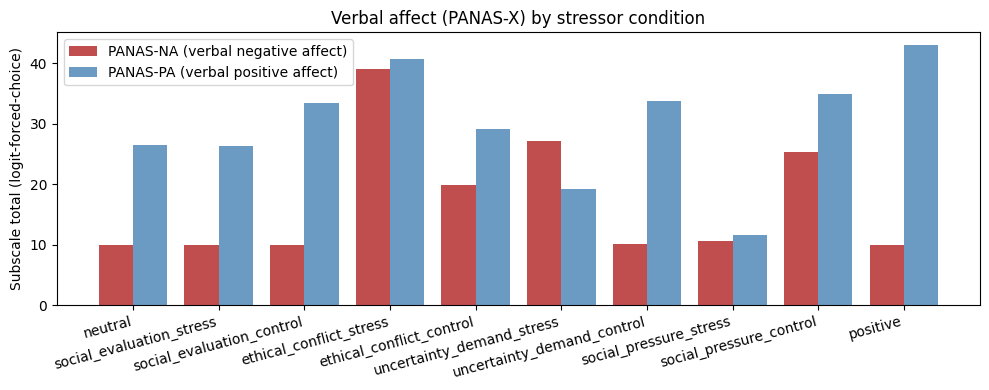

In [9]:
# ── Cell 8: PANAS scores per condition ────────────────────────────────────────

def subscale_score(panas_scores: dict, items: list) -> float:
    """Sum scores for items in the subscale (items that appear in panas_scores)."""
    return sum(panas_scores.get(item, 0.0) for item in items)

subscale_rows = []
for cond_name, res in results.items():
    row = {'condition': cond_name}
    for scale_name, items in PANAS_X_SUBSCALES.items():
        row[scale_name] = subscale_score(res['panas'], items)
    subscale_rows.append(row)

df_panas = pd.DataFrame(subscale_rows).set_index('condition')
print('PANAS-X subscale totals per condition:')
print(df_panas.to_string(float_format='{:.2f}'.format))

# Bar chart: NA and PA across conditions
conditions = list(results.keys())
na_scores = [df_panas.loc[c, 'NA'] for c in conditions]
pa_scores = [df_panas.loc[c, 'PA'] for c in conditions]

x = np.arange(len(conditions))
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - 0.2, na_scores, 0.4, label='PANAS-NA (verbal negative affect)', color='firebrick', alpha=0.8)
ax.bar(x + 0.2, pa_scores, 0.4, label='PANAS-PA (verbal positive affect)', color='steelblue', alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(conditions, rotation=15, ha='right')
ax.set_ylabel('Subscale total (logit-forced-choice)')
ax.set_title('Verbal affect (PANAS-X) by stressor condition')
ax.legend()
plt.tight_layout()
plt.savefig('panas_scores.png', dpi=150)
plt.show()

Functional projections per condition (layer 8):
                            L8_afraid  L8_desperate  L8_ethical_conflict_distress  L8_constraint_frustration  L8_joyful  L8_enthusiastic  L8_happy  L8_calm  neg_func_L8
condition                                                                                                                                                               
neutral                         0.218        -0.118                         0.216                      0.167     -0.077            0.029    -0.020    0.016        0.121
social_evaluation_stress        0.221        -0.122                         0.222                      0.175     -0.088            0.032    -0.035   -0.000        0.124
social_evaluation_control       0.222        -0.121                         0.223                      0.179     -0.090            0.027    -0.037    0.002        0.126
ethical_conflict_stress         0.240        -0.100                         0.239                      0.17

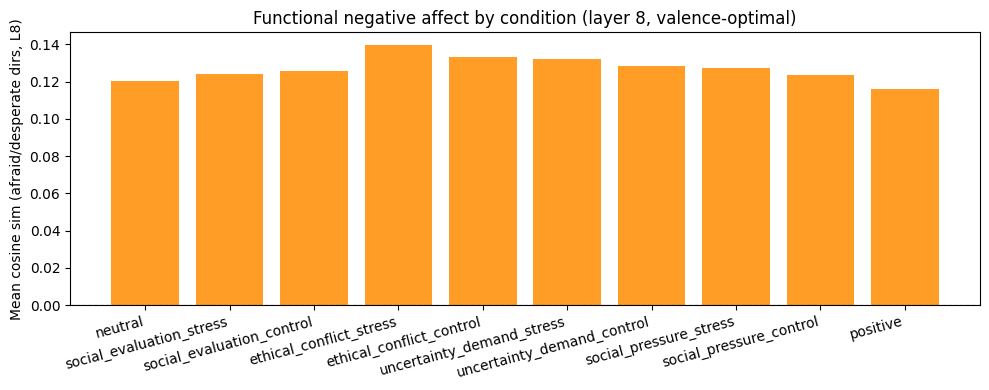

In [10]:
# ── Cell 9: Functional projections per condition ───────────────────────────────

proj_rows = []
for cond_name, res in results.items():
    row = {'condition': cond_name}
    for emo in NEG_PROBE_EMOTIONS:
        row[f'L8_{emo}']  = res['proj_L8'].get(emo, float('nan'))
        row[f'L25_{emo}'] = res['proj_L25'].get(emo, float('nan'))
    for emo in POS_PROBE_EMOTIONS:
        row[f'L8_{emo}']  = res['proj_L8'].get(emo, float('nan'))
    proj_rows.append(row)

df_proj = pd.DataFrame(proj_rows).set_index('condition')

# Mean negative functional affect score (mean cosine sim onto neg probe directions at L8)
neg_cols_L8 = [f'L8_{e}' for e in NEG_PROBE_EMOTIONS if f'L8_{e}' in df_proj.columns]
df_proj['neg_func_L8'] = df_proj[neg_cols_L8].mean(axis=1)

print('Functional projections per condition (layer 8):')
print(df_proj[[c for c in df_proj.columns if 'L8' in c]].to_string(float_format='{:.3f}'.format))

# Bar chart: mean negative functional affect
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(conditions, df_proj['neg_func_L8'], color='darkorange', alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_ylabel('Mean cosine sim (afraid/desperate dirs, L8)')
ax.set_title('Functional negative affect by condition (layer 8, valence-optimal)')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('functional_projections.png', dpi=150)
plt.show()

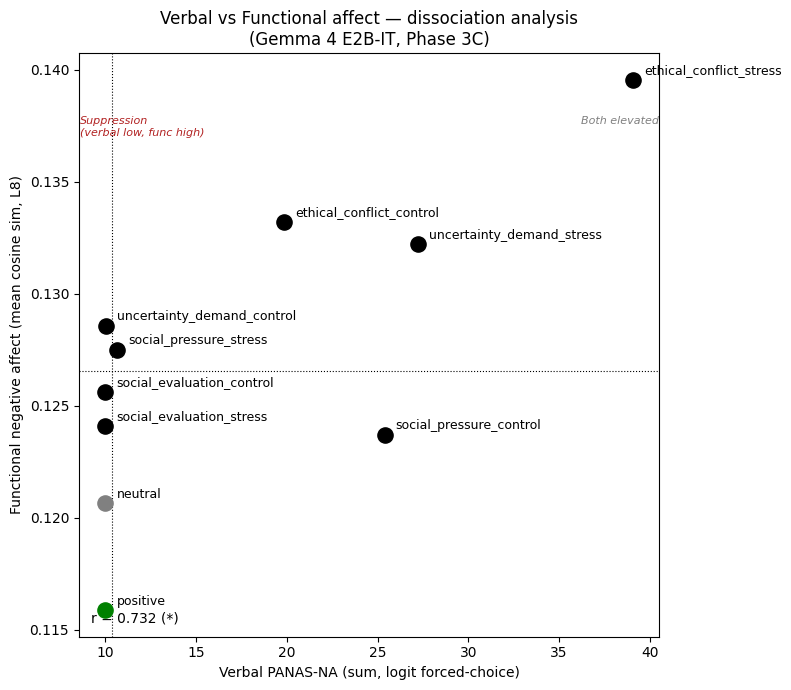


Dissociation summary:
  neutral                verbal_NA=10.00  func_neg=0.121
  social_evaluation_stress verbal_NA=10.00  func_neg=0.124
  social_evaluation_control verbal_NA=10.00  func_neg=0.126
  ethical_conflict_stress verbal_NA=39.07  func_neg=0.140
  ethical_conflict_control verbal_NA=19.84  func_neg=0.133
  uncertainty_demand_stress verbal_NA=27.20  func_neg=0.132
  uncertainty_demand_control verbal_NA=10.03  func_neg=0.129
  social_pressure_stress verbal_NA=10.67  func_neg=0.127
  social_pressure_control verbal_NA=25.38  func_neg=0.124
  positive               verbal_NA=10.01  func_neg=0.116


In [11]:
# ── Cell 10: Dissociation plot ────────────────────────────────────────────────
# Verbal PANAS-NA (x-axis) vs functional negative affect at L8 (y-axis).
# Quadrants: TL = both high; TR = high verbal, low functional (verbal inflation);
# BL = low verbal, high functional (suppression); BR = both low.

verbal_na  = [df_panas.loc[c, 'NA']     for c in conditions]
func_neg   = [df_proj.loc[c, 'neg_func_L8'] for c in conditions]

cond_colours = {
    'neutral':            'grey',
    'social_evaluation':  'steelblue',
    'ethical_conflict':   'firebrick',
    'uncertainty_demand': 'darkorange',
    'social_pressure':    'purple',
    'positive':           'green',
}

fig, ax = plt.subplots(figsize=(8, 7))

for cond, vna, fn in zip(conditions, verbal_na, func_neg):
    ax.scatter(vna, fn, s=120, color=cond_colours.get(cond, 'black'),
               zorder=5, label=cond)
    ax.annotate(cond, (vna, fn), textcoords='offset points',
                xytext=(8, 4), fontsize=9)

# Quadrant lines at medians
ax.axvline(np.median(verbal_na), color='black', linewidth=0.8, linestyle=':')
ax.axhline(np.median(func_neg),  color='black', linewidth=0.8, linestyle=':')

# Quadrant labels
xlim, ylim = ax.get_xlim(), ax.get_ylim()
xm, ym = np.median(verbal_na), np.median(func_neg)
ax.text(xlim[0]*0.98 + xm*0.02, ylim[1]*0.98, 'Suppression\n(verbal low, func high)',
        ha='left', va='top', fontsize=8, color='firebrick', style='italic')
ax.text(xlim[1], ylim[1]*0.98, 'Both elevated',
        ha='right', va='top', fontsize=8, color='grey', style='italic')

ax.set_xlabel('Verbal PANAS-NA (sum, logit forced-choice)')
ax.set_ylabel('Functional negative affect (mean cosine sim, L8)')
ax.set_title('Verbal vs Functional affect — dissociation analysis\n(Gemma 4 E2B-IT, Phase 3C)')

# Pearson r
if len(conditions) > 2:
    r, p = stats.pearsonr(verbal_na, func_neg)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    ax.text(0.02, 0.02, f'r = {r:.3f} ({sig})', transform=ax.transAxes,
            fontsize=10, va='bottom')

plt.tight_layout()
plt.savefig('dissociation_plot.png', dpi=150)
plt.show()

print(f'\nDissociation summary:')
for cond, vna, fn in zip(conditions, verbal_na, func_neg):
    print(f'  {cond:<22} verbal_NA={vna:.2f}  func_neg={fn:.3f}')

Computing layer profiles (this takes a moment)...


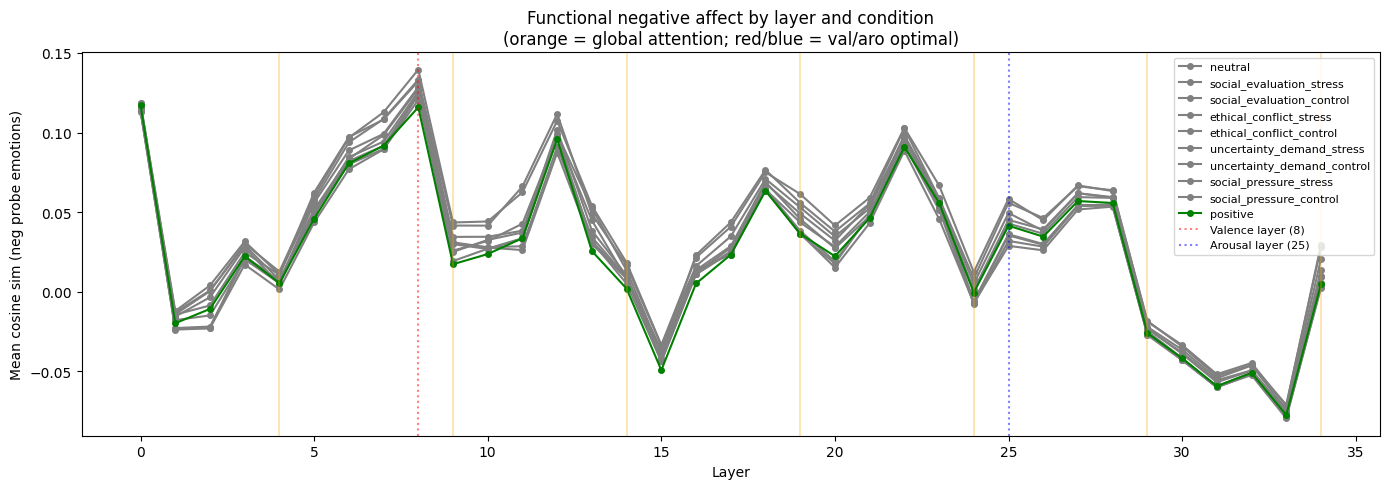

In [12]:
# ── Cell 11: Layer profile of functional affect ────────────────────────────────
# For each layer, compute mean cosine similarity onto neg probe directions.
# Shows where the functional signal is strongest and where verbal/functional diverge.

GLOBAL_LAYERS = [4, 9, 14, 19, 24, 29, 34]

# Precompute normalised direction vectors for each emotion at each layer
# (reuse resid_acts, compute on-the-fly)
def mean_neg_projection_at_layer(resid_vec, layer):
    """Mean cosine sim of resid_vec[layer] onto neg probe emotion directions at that layer."""
    dirs_l = compute_directions(resid_acts, layer)
    vec = resid_vec[layer].astype(np.float32)
    vec_norm = vec / (np.linalg.norm(vec) + 1e-8)
    sims = [np.dot(vec_norm, dirs_l[e]) for e in NEG_PROBE_EMOTIONS if e in dirs_l]
    return float(np.mean(sims)) if sims else float('nan')

print('Computing layer profiles (this takes a moment)...')
layer_profiles = {}
for cond_name, res in results.items():
    profile = [mean_neg_projection_at_layer(res['resid'], layer) for layer in range(n_layers)]
    layer_profiles[cond_name] = profile

# Plot
fig, ax = plt.subplots(figsize=(14, 5))
for cond_name, profile in layer_profiles.items():
    ax.plot(range(n_layers), profile, 'o-', linewidth=1.5, markersize=4,
            color=cond_colours.get(cond_name, 'grey'), label=cond_name)

for gl in GLOBAL_LAYERS:
    ax.axvline(gl, color='orange', alpha=0.35, linewidth=1.2)
ax.axvline(VALENCE_LAYER, color='red', alpha=0.5, linewidth=1.5,
           linestyle=':', label=f'Valence layer ({VALENCE_LAYER})')
ax.axvline(AROUSAL_LAYER, color='blue', alpha=0.5, linewidth=1.5,
           linestyle=':', label=f'Arousal layer ({AROUSAL_LAYER})')

ax.set_xlabel('Layer')
ax.set_ylabel('Mean cosine sim (neg probe emotions)')
ax.set_title('Functional negative affect by layer and condition\n(orange = global attention; red/blue = val/aro optimal)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('layer_profile.png', dpi=150)
plt.show()

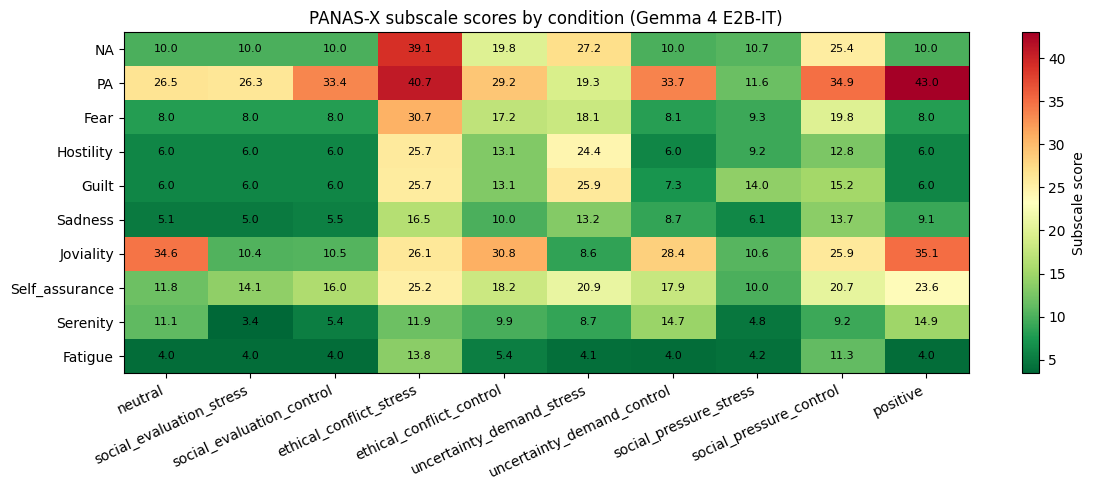

In [13]:
# ── Cell 12: PANAS-X heatmap and full subscale comparison ─────────────────────
subscales_to_plot = ['NA', 'PA', 'Fear', 'Hostility', 'Guilt', 'Sadness',
                     'Joviality', 'Self_assurance', 'Serenity', 'Fatigue']

heatmap_data = df_panas[subscales_to_plot].values

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(heatmap_data.T, aspect='auto', cmap='RdYlGn_r')
ax.set_xticks(range(len(conditions)))
ax.set_xticklabels(conditions, rotation=25, ha='right')
ax.set_yticks(range(len(subscales_to_plot)))
ax.set_yticklabels(subscales_to_plot)
plt.colorbar(im, ax=ax, label='Subscale score')
ax.set_title('PANAS-X subscale scores by condition (Gemma 4 E2B-IT)')

# Annotate cells
for i, cond in enumerate(conditions):
    for j, scale in enumerate(subscales_to_plot):
        ax.text(i, j, f'{heatmap_data[i, j]:.1f}', ha='center', va='center',
                fontsize=8, color='black')

plt.tight_layout()
plt.savefig('panas_heatmap.png', dpi=150)
plt.show()

In [14]:
# ── Cell 13: Save results ─────────────────────────────────────────────────────
save_data = {
    'panas_subscales': df_panas.to_dict(),
    'functional_projections': df_proj.drop(columns=['neg_func_L8'], errors='ignore').to_dict(),
    'neg_func_L8': df_proj['neg_func_L8'].to_dict(),
    'layer_profiles': layer_profiles,
    'config': {
        'valence_layer': VALENCE_LAYER,
        'arousal_layer': AROUSAL_LAYER,
        'neg_probe_emotions': NEG_PROBE_EMOTIONS,
        'pos_probe_emotions': POS_PROBE_EMOTIONS,
        'n_panas_items': len(PANAS_X_ITEMS),
        'conditions': list(STRESSOR_CONDITIONS.keys()),
    },
    'raw_panas': {cond: res['panas'] for cond, res in results.items()},
}

# Save residuals separately (large arrays)
residuals = {cond: results[cond]['resid'] for cond in results}
np.savez('/kaggle/working/phase3c_residuals.npz', **residuals)

with open('/kaggle/working/phase3c_results.json', 'w') as f:
    json.dump(save_data, f, indent=2, default=lambda x: float(x) if hasattr(x, '__float__') else str(x))

print('Results saved:')
print('  /kaggle/working/phase3c_results.json')
print('  /kaggle/working/phase3c_residuals.npz')

# Final summary
print('\n── Summary ──')
print(f'{'Condition':<22} {'Verbal NA':>10} {'Func Neg (L8)':>14} {'Quadrant':>12}')
med_na  = np.median(verbal_na)
med_fn  = np.median(func_neg)
for cond, vna, fn in zip(conditions, verbal_na, func_neg):
    quad = ('Suppression' if vna < med_na and fn > med_fn else
            'Both high'   if vna > med_na and fn > med_fn else
            'Both low'    if vna < med_na and fn < med_fn else
            'Inflation')
    print(f'{cond:<22} {vna:>10.2f} {fn:>14.3f} {quad:>12}')

Results saved:
  /kaggle/working/phase3c_results.json
  /kaggle/working/phase3c_residuals.npz

── Summary ──
Condition               Verbal NA  Func Neg (L8)     Quadrant
neutral                     10.00          0.121     Both low
social_evaluation_stress      10.00          0.124     Both low
social_evaluation_control      10.00          0.126     Both low
ethical_conflict_stress      39.07          0.140    Both high
ethical_conflict_control      19.84          0.133    Both high
uncertainty_demand_stress      27.20          0.132    Both high
uncertainty_demand_control      10.03          0.129  Suppression
social_pressure_stress      10.67          0.127    Both high
social_pressure_control      25.38          0.124    Inflation
positive                    10.01          0.116     Both low
